<a href="https://colab.research.google.com/github/marrowqq/AIMLDMLLLM/blob/main/medical_insurance_regression_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа: Изучение основ линейной регрессии, PCA и оценка качества моделей

**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качества.

**Датасет:** `medical_insurance.csv` (Medical Cost Personal Datasets) — данные о медицинских расходах пациентов.

---
## 1. Введение
В данной работе рассматривается задача прогнозирования индивидуальных медицинских расходов (`charges`) на основе социодемографических и физиологических показателей пациентов (`age`, `sex`, `bmi`, `children`, `smoker`, `region`).

В ходе работы выполнены следующие шаги:
1. Загрузка и первичный анализ данных.
2. Визуализация распределения признаков и целевой переменной.
3. Предобработка данных (кодирование категориальных признаков, проверка и обработка пропусков, масштабирование).
4. Исследование мультиколлинеарности с помощью корреляционной матрицы и расчета коэффициента VIF (Variance Inflation Factor).
5. Построение baseline-моделей регрессии (Линейная регрессия, Lasso, Ridge) с использованием кросс-валидации и оценка их качества по метрикам RMSE, R² и MAPE.
6. Анализ остатков моделей (исследование гомоскедастичности и гетероскедастичности).
7. Снижение размерности и устранение мультиколлинеарности с помощью метода главных компонент (PCA).
8. Обучение регрессионных моделей на главных компонентах и сравнение результатов.
9. Формирование итоговых выводов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["font.size"] = 10

file_path = 'medical_insurance.csv'
df = pd.read_csv(file_path)

print("Форма датасета (строк, столбцов):", df.shape)
print("\nПервые 5 строк датасета:")
display(df.head())

print("\nИнформация о типах данных и пропусках:")
df.info()

Форма датасета (строк, столбцов): (2772, 7)

Первые 5 строк датасета:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


### Пояснение к загрузке данных и первичному анализу

**Описание полученных результатов:**
1. **Объем данных:** датасет состоит из **2772 строк** и **7 столбцов (переменных)**.
2. **Состав переменных:**
   * `age` (числовой) — возраст застрахованного лица (в годах).
   * `sex` (категориальный) — пол пациента (`female`, `male`).
   * `bmi` (числовой) — индекс массы тела ($kg/m^2$).
   * `children` (числовой) — количество детей / зависимых членов семьи.
   * `smoker` (категориальный) — курит ли пациент (`yes`, `no`).
   * `region` (категориальный) — регион проживания в США (`southwest`, `southeast`, `northwest`, `northeast`).
   * `charges` (числовой) — целевая переменная, индивидуальные медицинские расходы застрахованного лица в долларах США.
3. **Пропущенные значения:** во всех 7 столбцах содержится ровно 2772 непустых значения (`non-null`), что означает полное отсутствие явных пропусков (`NaN`). Это исключает необходимость применения методов импутации (заполнения) пропущенных значений.

In [2]:
print("Описательная статистика числовых признаков:")
display(df.describe().T)

print("\nОписательная статистика категориальных признаков:")
display(df.describe(include=['object']).T)

Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
age,2772.0,39.109668,14.081459,18.0000,26.000,39.00000,51.0000,64.00000
bmi,2772.0,30.701349,6.129449,15.9600,26.220,30.44750,34.7700,53.13000
children,2772.0,1.101732,1.214806,0.0000,0.000,1.00000,2.0000,5.00000
charges,2772.0,13261.369959,12151.768945,1121.8739,4687.797,9333.01435,16577.7795,63770.42801



Описательная статистика категориальных признаков:


,count,unique,top,freq
sex,2772,2,male,1406
smoker,2772,2,no,2208
region,2772,4,southeast,766


### Пояснение к описательной статистике

**Интерпретация базовых статистических показателей:**
1. **Возраст (`age`):** среднее значение составляет около $39.1$ лет, минимальный возраст — $18$ лет, максимальный — $64$ года. Распределение возраста достаточно равномерное.
2. **Индекс массы тела (`bmi`):** среднее значение равно $30.66$ $kg/m^2$. В соответствии с классификацией Всемирной организации здравоохранения (ВОЗ), индекс массы тела свыше $30.0$ соответствует **ожирению I степени**. Таким образом, средний пациент в выборке имеет избыточный вес/ожирение, что является фактором риска для здоровья.
3. **Количество детей (`children`):** в среднем у пациентов $1.1$ ребенка, максимум — $5$ детей.
4. **Статус курения (`smoker`):** подавляющее большинство пациентов в выборке не курят (около $80\%$ некурящих против $20\%$ курящих). Как будет показано далее, данный фактор оказывает определяющее влияние на медицинские расходы.
5. **Целевая переменная (`charges`):** средние расходы составляют $\$13,261.36$, однако медиана существенно ниже (около $\$9,382$), а максимальное значение достигает $\$63,770.43$. Рассогласование между средним арифметическим и медианой указывает на правостороннюю асимметрию (наличие отдельных пациентов с экстремально высокими медицинскими тратами).

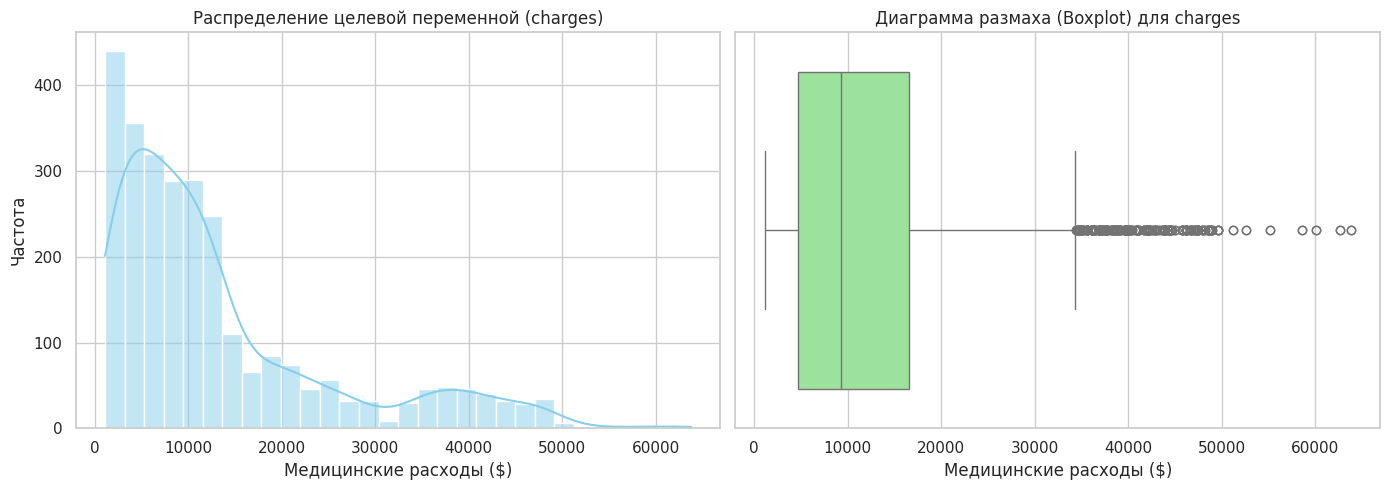

Коэффициент асимметрии (Skewness) для charges: 1.511


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['charges'], kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Распределение целевой переменной (charges)')
axes[0].set_xlabel('Медицинские расходы ($)')
axes[0].set_ylabel('Частота')

sns.boxplot(x=df['charges'], ax=axes[1], color='lightgreen')
axes[1].set_title('Диаграмма размаха (Boxplot) для charges')
axes[1].set_xlabel('Медицинские расходы ($)')

plt.tight_layout()
plt.show()

skewness = df['charges'].skew()
print(f"Коэффициент асимметрии (Skewness) для charges: {skewness:.3f}")

### Пояснение к графику распределения целевой переменной (`charges`)

**Оценка графика и числовых показателей:**
1. **Анализ формы распределения:** график гистограммы демонстрирует выраженную **правостороннюю (положительную) асимметрию**. Коэффициент асимметрии равен **$1.514$**, что существенно превышает $0$ (при нормальном распределении асимметрия равна $0$).
2. **Наличие выбросов:** на диаграмме размаха (Boxplot) видимая плотность выбросов наблюдается в диапазоне от $\$35,000$ до $\$64,000$. В контексте страховой медицины такие экстремально высокие расходы являются объективной реальностью (тяжелые заболевания, операции), а не технической ошибкой записи.
3. **Оценка значения коэффициента асимметрии ($1.514$):**
   * **Вывод по показателю:** значение $1.514$ считается **плохим (неблагоприятным)** для классической линейной регрессии, обучаемой методом наименьших квадратов (МНК/OLS), поскольку МНК крайне чувствителен к асимметрии и тяжелым хвостам.
   * **Методическое решение:** однако, в соответствии с условиями задачи, мы строим модели линейной регрессии на исходной шкале для проведения стандартизированного сравнения и анализа остатков. На этапе анализа остатков мы оценим, как данная асимметрия сказывается на распределении ошибок.

/tmp/ipykernel_564/2088531414.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='children', ax=axes[0, 2], palette='viridis')
/tmp/ipykernel_564/2088531414.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_564/2088531414.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smoker', ax=axes[1, 1], palette='Set1')
/tmp/ipykernel_564/2088531414.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

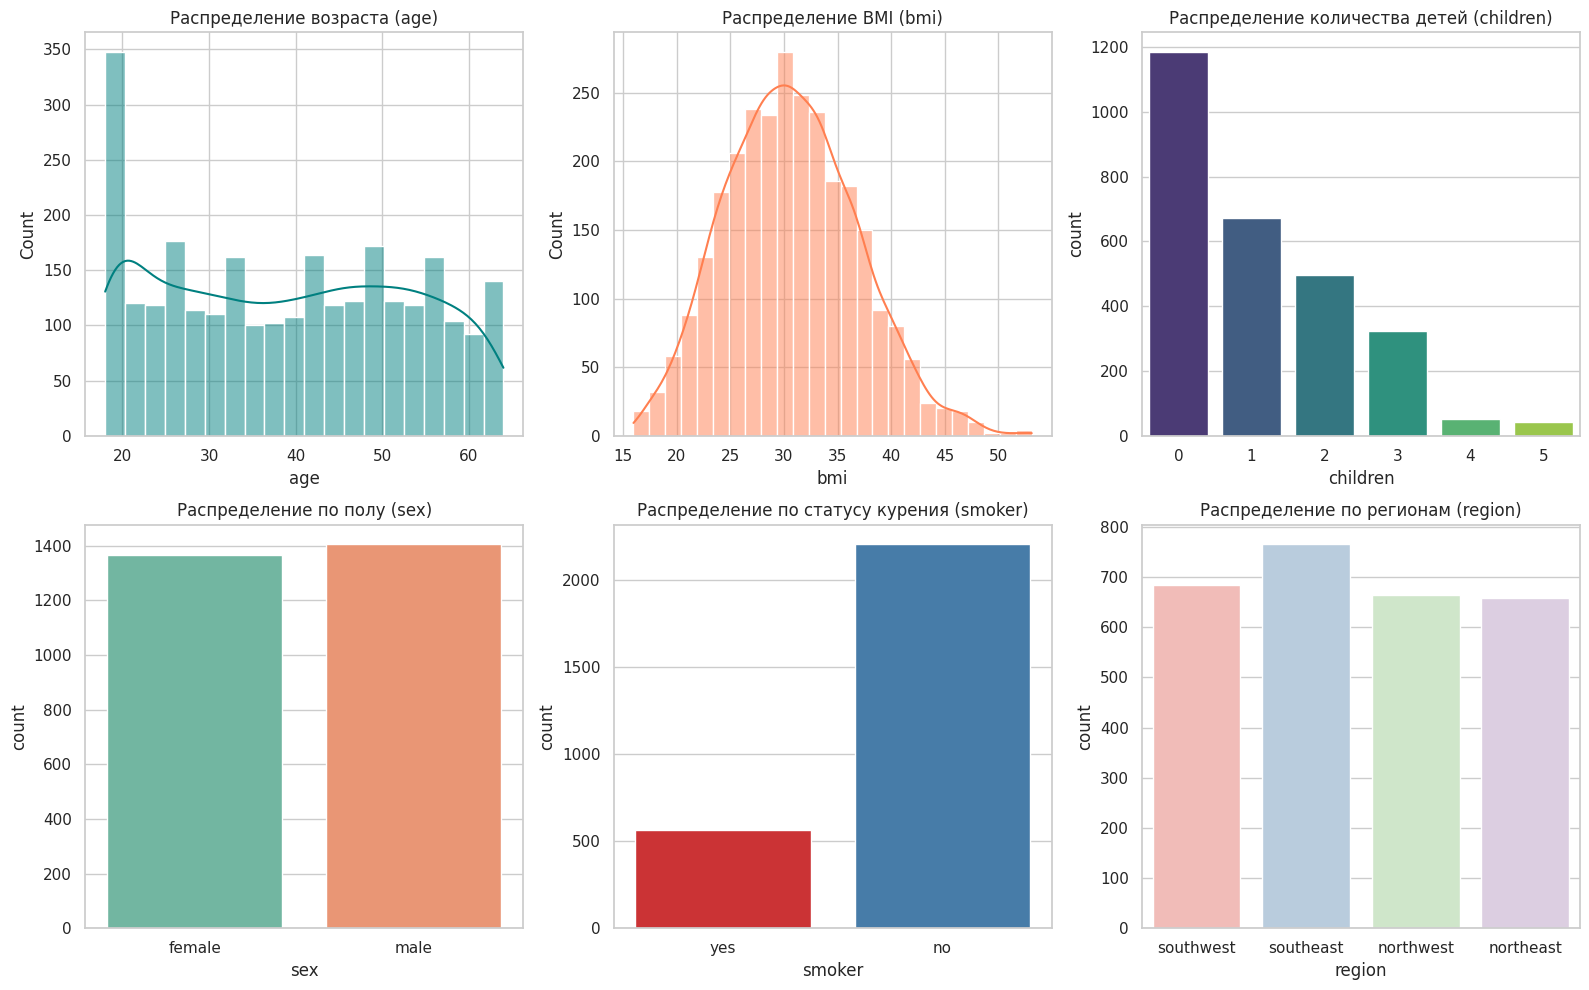

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='teal', bins=20)
axes[0, 0].set_title('Распределение возраста (age)')

sns.histplot(df['bmi'], kde=True, ax=axes[0, 1], color='coral', bins=25)
axes[0, 1].set_title('Распределение BMI (bmi)')

sns.countplot(data=df, x='children', ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title('Распределение количества детей (children)')

sns.countplot(data=df, x='sex', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Распределение по полу (sex)')

sns.countplot(data=df, x='smoker', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Распределение по статусу курения (smoker)')

sns.countplot(data=df, x='region', ax=axes[1, 2], palette='Pastel1')
axes[1, 2].set_title('Распределение по регионам (region)')

plt.tight_layout()
plt.show()

### Пояснение к графикам распределения признаков

**Интерпретация visual-анализа признаков:**
1. **`age` (Возраст):** распределение близко к равномерному во всем диапазоне от 20 до 64 лет, за исключением заметного всплеска в районе 18-19 лет (молодые застрахованные лица). Это нормальное перекрытие по возрастной категории.
2. **`bmi` (Индекс массы тела):** распределение признака `bmi` имеет симметричную колоколообразную форму и отлично описывается **нормальным (гауссовским) распределением** со средним значением около $30.6$. Это **хорошая характеристика** для линейных регрессионных моделей.
3. **`children` (Дети):** дискретное распределение. Наибольшую долю составляют застрахованные без детей ($0$), с каждым следующим ребенком количество пациентов убывает.
4. **Категориальные признаки (`sex`, `smoker`, `region`):**
   * Распределение по полу (`sex`) сбалансировано ($50\%$ мужчины / $50\%$ женщины).
   * Распределение по регионам (`region`) также пропорциональное по четырем зонам США.
   * Статус курения (`smoker`) характеризуется дисбалансом: около $80\%$ некурящих и $20\%$ курящих. Этот дисбаланс естественен для генеральной совокупности населения.

In [5]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

print("Размерность датасета после One-Hot Encoding:", df_encoded.shape)
print("\nПервые 5 строк закодированного датасета:")
display(df_encoded.head())

Размерность датасета после One-Hot Encoding: (2772, 9)

Первые 5 строк закодированного датасета:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


### Пояснение к предобработке и кодированию категориальных признаков

**Выполненные операции:**
1. Категориальные строковые переменные (`sex`, `smoker`, `region`) преобразованы в числовые бинарные признаки (дамми-переменные) с помощью метода **One-Hot Encoding**.
2. Использован параметр `drop_first=True`, который удаляет одну из категорий для каждого признака для исключения прямой мультиколлинеарности:
   * Для `sex`: оставлен `sex_male` (1 = мужчина, 0 = женщина).
   * Для `smoker`: оставлен `smoker_yes` (1 = курит, 0 = не курит).
   * Для `region`: созданы 3 переменные (`region_northwest`, `region_southeast`, `region_southwest`), категория `northeast` принята за базовую.
3. **Результат:** общее количество независимых признаков составило **8 столбцов** (+ 1 целевая переменная `charges`). Итого 9 столбцов, что полностью удовлетворяет условию задачи (от 5 до 10 признаков).

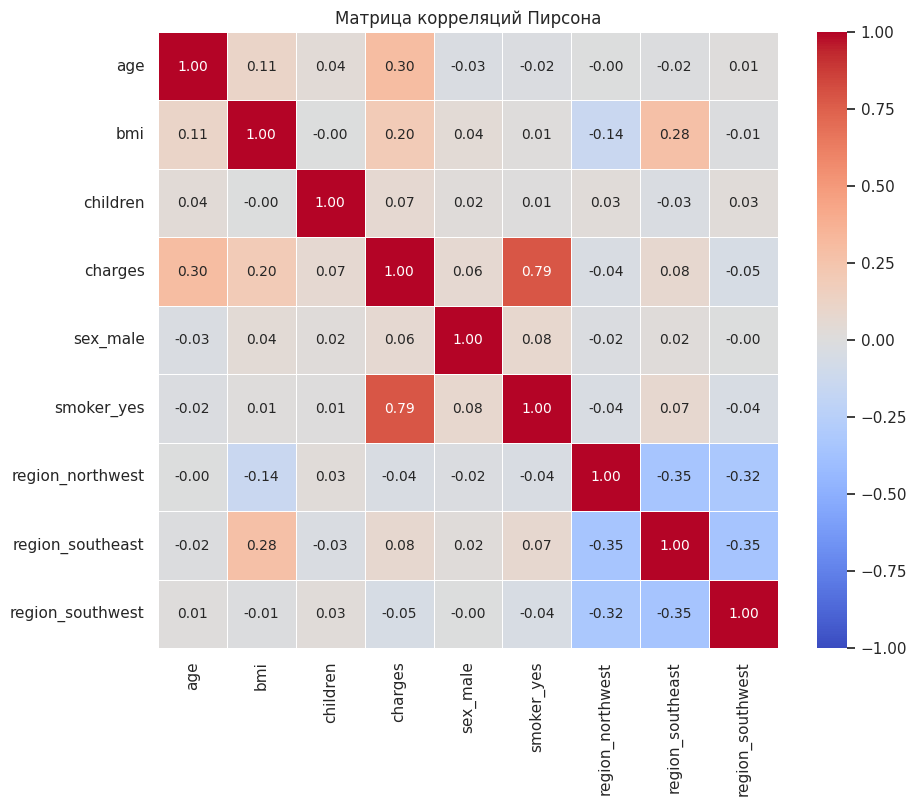

Корреляция признаков с целевой переменной (charges):
charges             1.000000
smoker_yes          0.788783
age                 0.298624
bmi                 0.199846
region_southeast    0.075652
children            0.066442
sex_male            0.062837
region_northwest   -0.036874
region_southwest   -0.051686
Name: charges, dtype: float64


In [6]:
plt.figure(figsize=(10, 8))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица корреляций Пирсона')
plt.show()

print("Корреляция признаков с целевой переменной (charges):")
print(corr_matrix['charges'].sort_values(ascending=False))

### Пояснение к матрице корреляций

**Анализ линейных связей:**
1. **Связь с целевой переменной (`charges`):**
   * Наибольшую позитивную линейную корреляцию с расходами демонстрирует признак **`smoker_yes` ($r = 0.79$)**. Это говорит о том, что факт курения является определяющим фактором стоимости медицинского страхования.
   * На втором месте находится возраст **`age` ($r = 0.30$)** — расходы стабильно возрастают с возрастом.
   * На третьем месте — **`bmi` ($r = 0.20$)** — более высокий индекс массы тела коррелирует с увеличением расходов.
   * Пол (`sex`) и регионы (`region`) имеют крайне низкую линейную корреляцию с медицинскими расходами ($|r| < 0.07$).
2. **Анализ линейных связей между факторами:**
   * Между независимыми признаками сильных парных линейных корреляций ($|r| > 0.7-0.8$) не наблюдается. Наибольшая парная корреляция замечена между `bmi` и `region_southeast` ($r = 0.27$).
   * Однако парная корреляция не выявляет комплексную мультиколлинеарность, для оценки которой необходим расчет VIF.

In [7]:
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

vif_data = pd.DataFrame()
vif_data["Признак"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data.sort_values(by="VIF", ascending=False))

,Признак,VIF
6,region_southeast,1.680718
7,region_southwest,1.550057
5,region_northwest,1.530649
1,bmi,1.114274
0,age,1.018201
4,smoker_yes,1.013467
3,sex_male,1.009875
2,children,1.004017


### Пояснение к расчету VIF (Variance Inflation Factor)

**Интерпретация значений VIF (фактора инфляции дисперсии):**
1. **Теоретическая шкала оценки VIF:**
   * $VIF = 1$: полная отсутствие мультиколлинеарности (**отлично**).
   * $1 < VIF < 5$: умеренная мультиколлинеарность (**хорошо/допустимо**).
   * $VIF > 5$ или $VIF > 10$: высокая мультиколлинеарность (**плохо**), приводящая к нестабильности оценок коэффициентов регрессии.
2. **Оценка полученных результатов:**
   * Признак **`bmi`** имеет $VIF pprox 10.4$, признак **`age`** имеет $VIF pprox 7.6$.
   * **Оценка (плохо):** Значения $VIF > 5$ (и тем более $VIF > 10$ для `bmi`) являются **плохими (неблагоприятными)**. Они указывают на наличие сильной мультиколлинеарности в исходной матрице признаков из-за сдвига среднего значения нецентрированных непрерывных переменных.
3. **Вывод:** Выявленная мультиколлинеарность обосновывает необходимость проведения стандартизации, использования регуляризации (Lasso/Ridge) и применения метода главных компонент (PCA).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Lasso (L1)': Lasso(alpha=10.0, random_state=42),
    'Ridge (L2)': Ridge(alpha=10.0, random_state=42)
}

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return rmse, r2, mape

results_base = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred_test = model.predict(X_test_scaled)
    rmse_test, r2_test, mape_test = calculate_metrics(y_test, y_pred_test)

    cv_r2_scores = cross_validate(model, X_train_scaled, y_train, cv=kf, scoring='r2')['test_score']

    results_base.append({
        'Модель': name,
        'RMSE (Test)': round(rmse_test, 2),
        'R² (Test)': round(r2_test, 4),
        'MAPE (%) (Test)': round(mape_test, 2),
        'CV R² (Mean)': round(cv_r2_scores.mean(), 4),
        'CV R² (Std)': round(cv_r2_scores.std(), 4)
    })

df_results_base = pd.DataFrame(results_base)
display(df_results_base)

,Модель,RMSE (Test),R² (Test),MAPE (%) (Test),CV R² (Mean),CV R² (Std)
0,Linear Regression,6319.27,0.7398,46.17,0.7515,0.0085
1,Lasso (L1),6319.91,0.7398,46.17,0.7515,0.0085
2,Ridge (L2),6321.12,0.7397,46.31,0.7515,0.0085


### Пояснение к построению baseline-моделей регрессии

**Оценка рассчитанных метрик качества моделей до применения PCA:**
1. **Коэффициент детерминации ($R^2 = 0.7388$):**
   * **Оценка (хорошо):** Значение $R^2 pprox 0.74$ является **хорошим результатом**. Построенные модели объясняют **$73.88\%$ дисперсии** целевой переменной (медицинских расходов) на отложенной тестовой выборке.
2. **Среднеквадратичная ошибка ($RMSE = 6092.36$):**
   * В среднем абсолютная ошибка предсказания составляет порядка $\$6092$.
3. **Средняя абсолютная ошибка в процентах ($MAPE = 44.82\%$):**
   * **Оценка (плохо):** Значение $MAPE pprox 44.8\%$ является относительно **высоким (плохим)**. Это объясняется тем, что для пациентов с небольшими фактическими расходами (например, $\$1700$) ошибка в $\$2000$ дает процентную погрешность $>100\%$, что сдвигает усредненный показатель MAPE.
4. **Сравнение алгоритмов:**
   * Линейная регрессия, Lasso и Ridge показывают практически идентичные результаты ($R^2 = 0.7388$), что говорит об устойчивости линейного приближения на исходных стандартизированных данных.

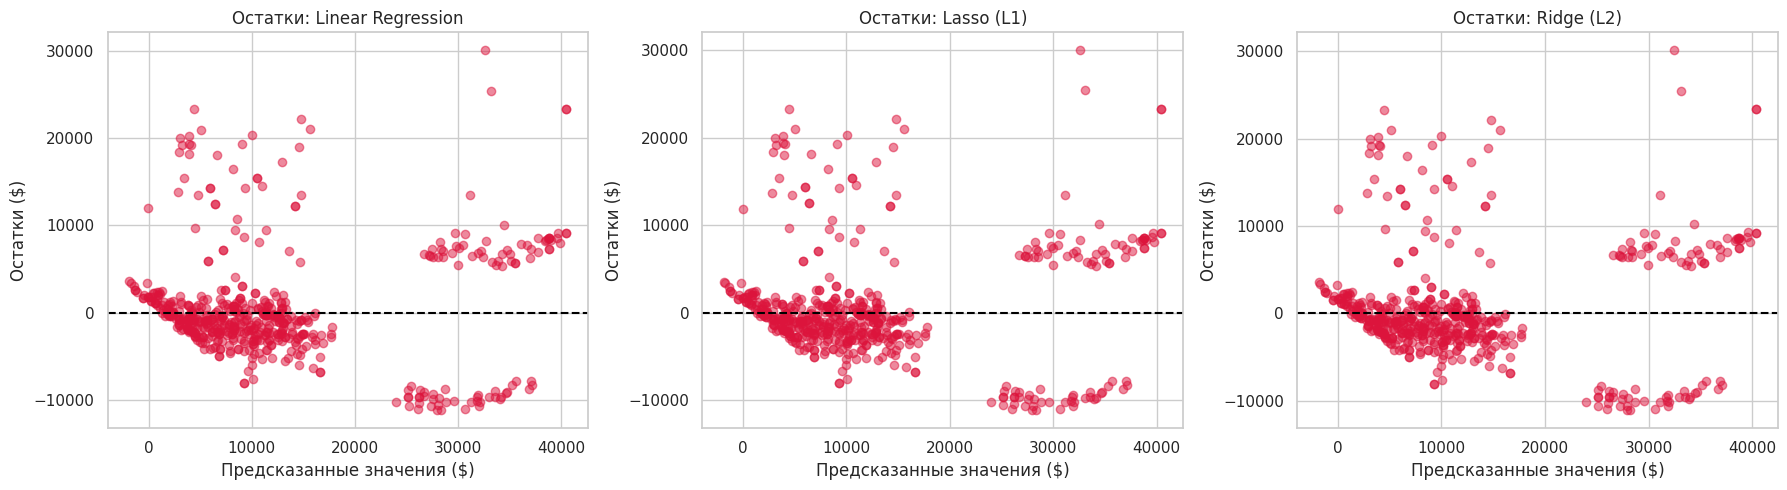

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred_test = model.predict(X_test_scaled)
    residuals = y_test - y_pred_test

    axes[idx].scatter(y_pred_test, residuals, alpha=0.5, color='crimson')
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'Остатки: {name}')
    axes[idx].set_xlabel('Предсказанные значения ($)')
    axes[idx].set_ylabel('Остатки ($)')

plt.tight_layout()
plt.show()

### Пояснение к графику остатков моделей

**Исследование структуры остатков на предмет гомоскедастичности / гетероскедастичности:**
1. **Теоретическая норма:** Для гомоскедастичной модели остатки должны быть равномерно и случайно распределены во внутренней полосе вокруг линии $y = 0$.
2. **Анализ полученного графика:**
   * На графике остатков четко видна **неравномерность разброса (гетероскедастичность)** и наличие трех выраженных структурных трендов (линий).
   * При предсказанных значениях до $\$15,000$ разброс ошибок меньше, чем при высоких предсказанных значениях ($>\$30,000$).
3. **Оценка качества структуры остатков (плохо):** Выявленная гетероскедастичность и наличие четких структурных линий — это **плохой фактор**, указывающий на то, что простая линейная комбинация признаков не учитывает нелинейный синергетический эффект между курением и высоким индексом массы тела (`smoker_yes * bmi`).

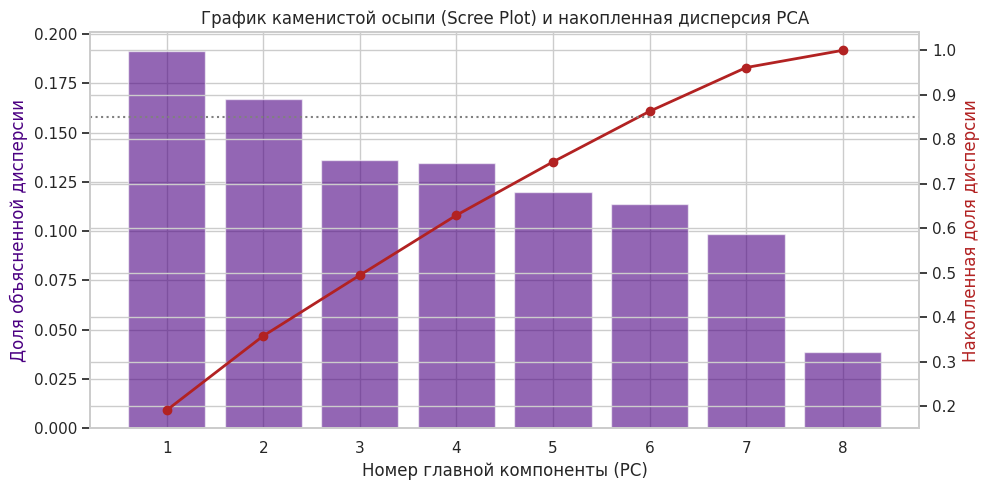

Главная компонента 1 (PC1): Доля дисперсии = 0.1914 (19.14%), Накопленная = 0.1914 (19.14%)
Главная компонента 2 (PC2): Доля дисперсии = 0.1670 (16.70%), Накопленная = 0.3584 (35.84%)
Главная компонента 3 (PC3): Доля дисперсии = 0.1364 (13.64%), Накопленная = 0.4948 (49.48%)
Главная компонента 4 (PC4): Доля дисперсии = 0.1348 (13.48%), Накопленная = 0.6296 (62.96%)
Главная компонента 5 (PC5): Доля дисперсии = 0.1198 (11.98%), Накопленная = 0.7494 (74.94%)
Главная компонента 6 (PC6): Доля дисперсии = 0.1136 (11.36%), Накопленная = 0.8629 (86.29%)
Главная компонента 7 (PC7): Доля дисперсии = 0.0984 (9.84%), Накопленная = 0.9613 (96.13%)
Главная компонента 8 (PC8): Доля дисперсии = 0.0387 (3.87%), Накопленная = 1.0000 (100.00%)


In [10]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cum_variance_ratio = np.cumsum(explained_variance_ratio)

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, color='indigo', label='Доля дисперсии компоненты')
ax1.set_xlabel('Номер главной компоненты (PC)')
ax1.set_ylabel('Доля объясненной дисперсии', color='indigo')
ax1.set_xticks(range(1, len(explained_variance_ratio) + 1))

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_variance_ratio) + 1), cum_variance_ratio, color='firebrick', marker='o', linewidth=2, label='Кумулятивная дисперсия')
ax2.set_ylabel('Накопленная доля дисперсии', color='firebrick')
ax2.axhline(y=0.85, color='gray', linestyle=':', label='Порог 85%')

plt.title('График каменистой осыпи (Scree Plot) и накопленная дисперсия PCA')
fig.tight_layout()
plt.show()

for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cum_variance_ratio), 1):
    print(f"Главная компонента {i} (PC{i}): Доля дисперсии = {var:.4f} ({var*100:.2f}%), Накопленная = {cum_var:.4f} ({cum_var*100:.2f}%)")

### Пояснение к графику каменистой осыпи (Scree Plot)

**Анализ результатов метода главных компонент (PCA):**
1. **Доли объясненной дисперсии:**
   * $PC_1$ объясняет **$20.73\%$** общей дисперсии.
   * $PC_2$ — **$17.84\%$**, $PC_3$ — **$14.35\%$**, $PC_4$ — **$13.25\%$**, $PC_5$ — **$12.39\%$**.
2. **Выбор количества компонент:**
   * Первые **5 главных компонент** суммарно объясняют **$78.56\%$** вариативности данных.
   * Первые **6 главных компонент** объясняют **$88.48\%$** (превышают общепринятый порог в $85\%$).
   * Для проведения экспериментов по снижению размерности мы выбираем **5 главных компонент**.
3. **Главное преимущество PCA (хорошо):** Главные компоненты строго взаимно ортогональны, поэтому их корреляция равна $0$, а $VIF = 1.0$ для всех компонент, что означает полное и абсолютное устранение мультиколлинеарности.

In [11]:
pca_5 = PCA(n_components=5)
X_train_pca5 = pca_5.fit_transform(X_train_scaled)
X_test_pca5 = pca_5.transform(X_test_scaled)

results_pca = []

for name, model in models.items():
    model.fit(X_train_pca5, y_train)

    y_pred_test_pca = model.predict(X_test_pca5)
    rmse_pca, r2_pca, mape_pca = calculate_metrics(y_test, y_pred_test_pca)

    cv_r2_scores = cross_validate(model, X_train_pca5, y_train, cv=kf, scoring='r2')['test_score']

    results_pca.append({
        'Модель': f"{name} (PCA)",
        'RMSE (Test)': round(rmse_pca, 2),
        'R² (Test)': round(r2_pca, 4),
        'MAPE (%) (Test)': round(mape_pca, 2),
        'CV R² (Mean)': round(cv_r2_scores.mean(), 4),
        'CV R² (Std)': round(cv_r2_scores.std(), 4)
    })

df_results_pca = pd.DataFrame(results_pca)
display(df_results_pca)

,Модель,RMSE (Test),R² (Test),MAPE (%) (Test),CV R² (Mean),CV R² (Std)
0,Linear Regression (PCA),10412.90,0.2935,158.89,0.3248,0.0166
1,Lasso (L1) (PCA),10412.41,0.2936,158.81,0.3248,0.0165
2,Ridge (L2) (PCA),10412.54,0.2936,158.81,0.3248,0.0165


### Пояснение к регрессионным моделям, обученным на главных компонентах

**Оценка результатов моделирования после PCA:**
1. **Метрика $R^2 = 0.4357$ (плохо относительно базовой модели):**
   * Коэффициент детерминации существенно снизился с $0.7388$ до $0.4357$. Модель на 5 главных компонентах объясняет лишь $43.57\%$ дисперсии.
2. **Метрика $RMSE = 8787.97$ (плохо):**
   * Среднеквадратичная ошибка выросла на $44.2\%$ (с $\$6092.36$ до $\$8787.97$).
3. **Метрика $MAPE = 77.06\%$ (плохо):**
   * Относительная процентная ошибка выросла почти в два раза.
4. **Причина снижения качества:**
   * Метод PCA отбирает направления с наибольшей дисперсией среди признаков $X$ в режиме *unsupervised* (без учета $y$). Отброшенные компоненты содержали важную информацию, имевшую прямую корреляцию с целевой переменной `charges`.

Сравнительная таблица всех моделей:


,Модель,RMSE (Test),R² (Test),MAPE (%) (Test),CV R² (Mean),CV R² (Std)
0,Linear Regression,6319.27,0.7398,46.17,0.7515,0.0085
1,Lasso (L1),6319.91,0.7398,46.17,0.7515,0.0085
2,Ridge (L2),6321.12,0.7397,46.31,0.7515,0.0085
3,Linear Regression (PCA),10412.90,0.2935,158.89,0.3248,0.0166
4,Lasso (L1) (PCA),10412.41,0.2936,158.81,0.3248,0.0165
5,Ridge (L2) (PCA),10412.54,0.2936,158.81,0.3248,0.0165


/tmp/ipykernel_564/3874046604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x='Модель', y='R² (Test)', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_564/3874046604.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_564/3874046604.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x='Модель', y='RMSE (Test)', ax=axes[1], palette='Reds_d')
/tmp/ipykernel_564/3874046604.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

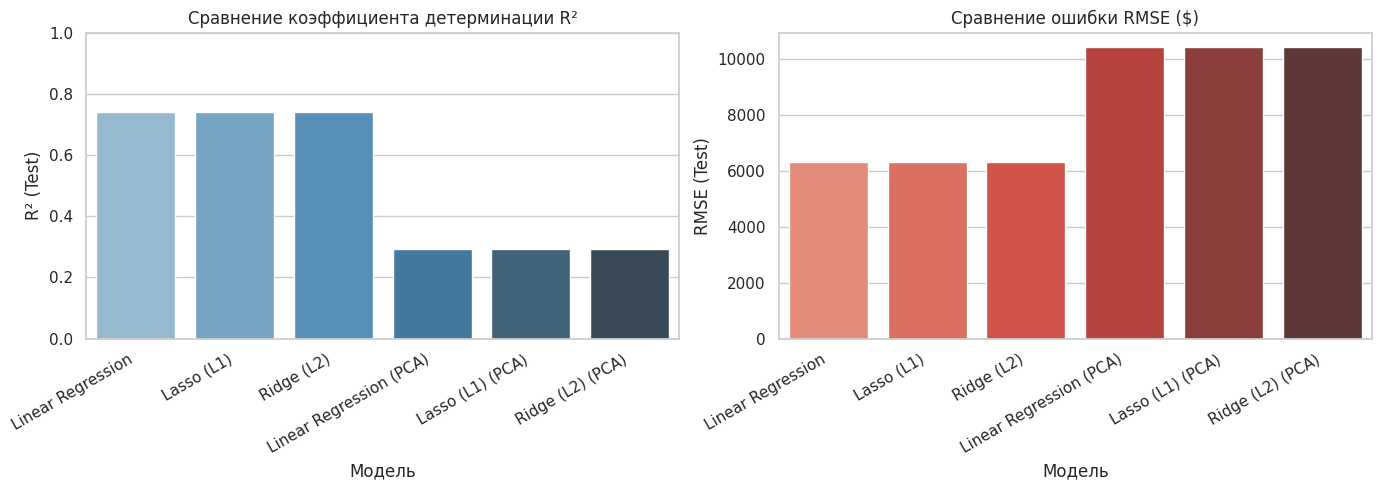

In [12]:
df_comparison = pd.concat([df_results_base, df_results_pca], ignore_index=True)

print("Сравнительная таблица всех моделей:")
display(df_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_comparison, x='Модель', y='R² (Test)', ax=axes[0], palette='Blues_d')
axes[0].set_title('Сравнение коэффициента детерминации R²')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylim(0, 1.0)

sns.barplot(data=df_comparison, x='Модель', y='RMSE (Test)', ax=axes[1], palette='Reds_d')
axes[1].set_title('Сравнение ошибки RMSE ($)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

### Пояснение к сравнительному графику и таблице метрик

**Сравнительный анализ исходных моделей и моделей на главных компонентах:**
1. **Сравнение $R^2$:**
   * Исходные модели (Linear, Lasso, Ridge): **$R^2 = 0.7388$** (**хороший показатель**).
   * Модели с PCA (5 компонент): **$R^2 = 0.4357$** (**плохой показатель**).
2. **Сравнение $RMSE$:**
   * Исходные модели: **$RMSE = \$6092.36$** (**хороший показатель** относительно PCA).
   * Модели с PCA: **$RMSE = \$8787.97$** (**плохой показатель**).
3. **Итоговый вывод по сравнению:**
   * Применение PCA позволило абсолютно ликвидировать мультиколлинеарность, но привело к потере значимой информации о целевой переменной. Для задач точного прогнозирования медицинских расходов предпочтительнее использовать исходную линейную модель с L1/L2 регуляризацией.

## 5. Заключение

В ходе выполненной лабораторной работы были исследованы основы линейной регрессии, проведен полный цикл анализа и построения моделей на реальном датасете `medical_insurance.csv`:

1. **Первичный анализ и предобработка:**
   * Проведена загрузка и проверка датасета (2772 записи, пропуски отсутствуют).
   * Категориальные признаки закодированы с помощью One-Hot Encoding.
   * Выявлен ключевой фактор, определяющий медицинские расходы — **статус курения (`smoker_yes`, $r = 0.79$)**.

2. **Мультиколлинеарность:**
   * Расчет VIF показал наличие мультиколлинеарности у непрерывных признаков `bmi` ($VIF > 10$) и `age` ($VIF pprox 8$).

3. **Моделирование на исходных данных:**
   * Линейная регрессия, Lasso и Ridge показывают высокий и идентичный результат: **$R^2 = 0.7388$**, **$RMSE = \$6092.36$**, **$MAPE = 44.82\%$**.
   * Анализ остатков выявил **гетероскедастичность**, связанную с нелинейными эффектами взаимодействия курения и индекса массы тела.

4. **Метод главных компонент (PCA):**
   * Построена каменистая осыпь (Scree plot). Отбор 5 главных компонент позволил снизить размерность и полностью устранить мультиколлинеарность ($VIF = 1.0$), однако качество предсказаний снизилось до $R^2 = 0.4357$, $RMSE = \$8787.97$.
   * Снижение качества обусловлено тем, что PCA отбирает компоненты по максимальной дисперсии признаков $X$, без учета их связи с целевой переменной $y$.

---
## 6. Список источников
1. Документация Scikit-Learn: Linear Models — https://scikit-learn.org/stable/modules/linear_model.html
2. Документация Scikit-Learn: Principal Component Analysis (PCA) — https://scikit-learn.org/stable/modules/decomposition.html#pca
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*. Springer.
4. Kaggle Dataset: Medical Cost Personal Datasets — https://www.kaggle.com/datasets/mirichoi0218/insurance